# Traditional ML Classifiers for Beehive Audio

Based on Chen et al. (2024) which achieved 98.8% accuracy using SVM and Random Forest.

This notebook implements:
1. MFCC feature extraction (39 features: 13 MFCCs + deltas)
2. SMOTE for class balancing
3. SVM, Random Forest, and XGBoost classifiers
4. Cross-validation evaluation


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

import librosa
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score
)
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
import joblib

# Paths
OUTPUT_DIR = Path('../outputs')
PROCESSED_DIR = OUTPUT_DIR / 'processed'
MODEL_DIR = OUTPUT_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# Load configuration
with open(PROCESSED_DIR / 'config.json', 'r') as f:
    config = json.load(f)

CLASS_NAMES = {int(k): v for k, v in config['class_names'].items()}
print(f"Classes: {CLASS_NAMES}")


Classes: {0: 'Queenright', 1: 'Queenless', 2: 'Queen_New', 3: 'Queen_Accepted'}


## 1. Load Data Splits


In [ ]:
train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_split.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Combine train and val for traditional ML (we'll use cross-validation)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
print(f"\nTrain+Val: {len(train_val_df)} samples")

# Class distribution
print("\nClass distribution in Train+Val:")
print(train_val_df['class_name'].value_counts())


Train: 4967 samples
Val: 711 samples
Test: 1422 samples

Train+Val: 5678 samples

Class distribution in Train+Val:
class_name
Queen_Accepted    2850
Queen_New         1243
Queenright         829
Queenless          756
Name: count, dtype: int64


## 2. Feature Extraction (MFCCs)


In [ ]:
def extract_mfcc_features(audio_path, sr=22050, n_mfcc=13, duration=10.0):
    """
    Extract MFCC features from audio file.
    Returns 78 features: (13 MFCCs + 13 deltas + 13 delta-deltas) x (mean + std)
    """
    try:
        # Load audio
        y, _ = librosa.load(audio_path, sr=sr, duration=duration, mono=True)
        
        # Pre-emphasis
        y = np.append(y[0], y[1:] - 0.97 * y[:-1])
        
        # Normalize
        if np.abs(y).max() > 0:
            y = y / np.abs(y).max()
        
        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
        
        # Compute deltas
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        
        # Stack all features: (39, time_steps)
        all_features = np.vstack([mfcc, delta, delta2])
        
        # Aggregate over time: mean and std for each feature
        mean_features = np.mean(all_features, axis=1)
        std_features = np.std(all_features, axis=1)
        
        # Concatenate: 39 means + 39 stds = 78 features
        features = np.concatenate([mean_features, std_features])
        
        return features
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Test on one file
sample_path = train_df.iloc[0]['audio_path']
sample_features = extract_mfcc_features(sample_path)
print(f"Feature vector shape: {sample_features.shape}")


Feature vector shape: (78,)


In [ ]:
def extract_features_from_df(df, desc="Extracting"):
    """Extract features from all audio files in DataFrame."""
    features = []
    labels = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        feat = extract_mfcc_features(row['audio_path'])
        if feat is not None:
            features.append(feat)
            labels.append(row['queen_status'])
    
    return np.array(features), np.array(labels)

print("Extracting features from Train+Val...")
X_train_val, y_train_val = extract_features_from_df(train_val_df, "Train+Val")

print("\nExtracting features from Test...")
X_test, y_test = extract_features_from_df(test_df, "Test")

print(f"\nTrain+Val: X={X_train_val.shape}, y={y_train_val.shape}")
print(f"Test: X={X_test.shape}, y={y_test.shape}")


Extracting features from Train+Val...



Train+Val:   0%|          | 0/5678 [00:00<?, ?it/s]


Train+Val:   0%|          | 10/5678 [00:00<00:56, 99.74it/s]


Train+Val:   0%|          | 22/5678 [00:00<00:50, 111.53it/s]


Train+Val:   1%|          | 35/5678 [00:00<00:48, 115.35it/s]

...


Test:  98%|█████████▊| 1389/1422 [00:11<00:00, 131.03it/s]


Test:  99%|█████████▊| 1404/1422 [00:11<00:00, 133.98it/s]


Test: 100%|█████████▉| 1418/1422 [00:11<00:00, 133.69it/s]


Test: 100%|██████████| 1422/1422 [00:11<00:00, 124.66it/s]


Train+Val: X=(5678, 78), y=(5678,)
Test: X=(1422, 78), y=(1422,)


## 3. Apply SMOTE for Class Balancing


In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

print("Before SMOTE:")
unique, counts = np.unique(y_train_val, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({CLASS_NAMES[u]}): {c} samples")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_val_scaled, y_train_val)

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_resampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({CLASS_NAMES[u]}): {c} samples")


Before SMOTE:
  Class 0 (Queenright): 829 samples
  Class 1 (Queenless): 756 samples
  Class 2 (Queen_New): 1243 samples
  Class 3 (Queen_Accepted): 2850 samples

After SMOTE:
  Class 0 (Queenright): 2850 samples
  Class 1 (Queenless): 2850 samples
  Class 2 (Queen_New): 2850 samples
  Class 3 (Queen_Accepted): 2850 samples


## 4. Train and Evaluate Classifiers


In [ ]:
# Define classifiers
classifiers = {
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Train
    clf.fit(X_train_resampled, y_train_resampled)
    
    # Predict on test set
    y_pred = clf.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'accuracy': acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'model': clf,
        'predictions': y_pred
    }
    
    print(f"\nTest Results:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=[CLASS_NAMES[i] for i in range(4)]))



Training SVM (RBF)...



Test Results:
  Accuracy:  0.7300
  F1 Score:  0.7293
  Precision: 0.7296
  Recall:    0.7300

Classification Report:
                precision    recall  f1-score   support

    Queenright       0.65      0.73      0.69       209
     Queenless       0.53      0.52      0.53       190
     Queen_New       0.65      0.61      0.63       310
Queen_Accepted       0.84      0.84      0.84       713

      accuracy                           0.73      1422
     macro avg       0.67      0.68      0.67      1422
  weighted avg       0.73      0.73      0.73      1422


Training Random Forest...



Test Results:
  Accuracy:  0.7525
  F1 Score:  0.7473
  Precision: 0.7483
  Recall:    0.7525

Classification Report:
                precision    recall  f1-score   support

    Queenright       0.71      0.68      0.70       209
     Queenless       0.62      0.57      0.60       190
     Queen_New       0.75      0.60      0.67       310
Queen_Accepted       0.79      0.88      0.84       713

      accuracy                           0.75      1422
     macro avg       0.72      0.69      0.70      1422
  weighted avg       0.75      0.75      0.75      1422


Training XGBoost...



Test Results:
  Accuracy:  0.7883
  F1 Score:  0.7873
  Precision: 0.7877
  Recall:    0.7883

Classification Report:
                precision    recall  f1-score   support

    Queenright       0.73      0.78      0.75       209
     Queenless       0.63      0.64      0.64       190
     Queen_New       0.78      0.69      0.73       310
Queen_Accepted       0.85      0.88      0.86       713

      accuracy                           0.79      1422
     macro avg       0.75      0.74      0.75      1422
  weighted avg       0.79      0.79      0.79      1422



In [ ]:
# Summary comparison
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 Score': [r['f1_score'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()]
}).sort_values('F1 Score', ascending=False)

print(summary_df.to_string(index=False))

# Best model
best_model_name = summary_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n Best Model: {best_model_name}")



MODEL COMPARISON SUMMARY
        Model  Accuracy  F1 Score  Precision   Recall
      XGBoost  0.788326  0.787287   0.787679 0.788326
Random Forest  0.752461  0.747256   0.748326 0.752461
    SVM (RBF)  0.729958  0.729286   0.729618 0.729958

 Best Model: XGBoost


## 5. Confusion Matrices


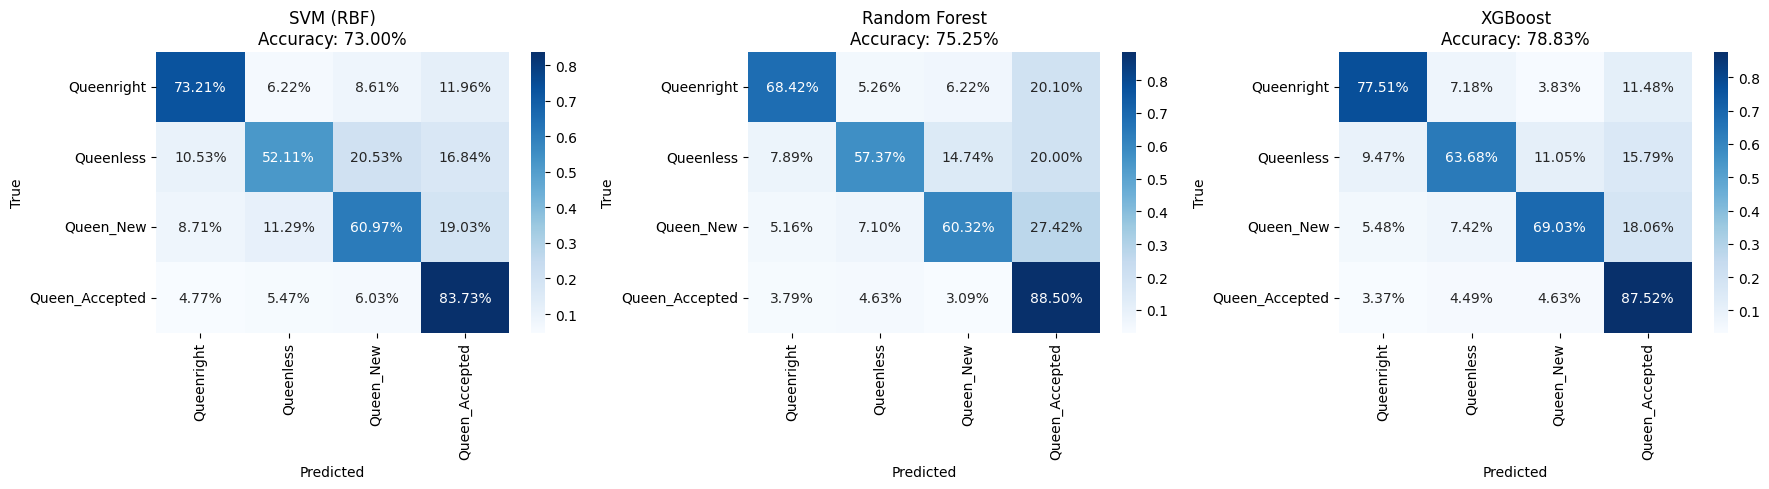

Saved confusion matrices to ../outputs/traditional_ml_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=[CLASS_NAMES[i] for i in range(4)],
                yticklabels=[CLASS_NAMES[i] for i in range(4)])
    ax.set_title(f'{name}\nAccuracy: {result["accuracy"]:.2%}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'traditional_ml_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved confusion matrices to {OUTPUT_DIR / 'traditional_ml_confusion_matrices.png'}")


## 6. Cross-Validation on Best Model


In [ ]:
# 5-fold cross-validation on the best model
print(f"\n5-Fold Cross-Validation for {best_model_name}:")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_val_scaled, y_train_val)):
    X_fold_train, X_fold_val = X_train_val_scaled[train_idx], X_train_val_scaled[val_idx]
    y_fold_train, y_fold_val = y_train_val[train_idx], y_train_val[val_idx]
    
    # Apply SMOTE on training fold only
    smote_fold = SMOTE(random_state=42)
    X_fold_resampled, y_fold_resampled = smote_fold.fit_resample(X_fold_train, y_fold_train)
    
    # Clone and train
    if best_model_name == 'SVM (RBF)':
        fold_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
    elif best_model_name == 'Random Forest':
        fold_clf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    else:
        fold_clf = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    
    fold_clf.fit(X_fold_resampled, y_fold_resampled)
    y_fold_pred = fold_clf.predict(X_fold_val)
    fold_acc = accuracy_score(y_fold_val, y_fold_pred)
    cv_scores.append(fold_acc)
    print(f"  Fold {fold+1}: {fold_acc:.4f}")

print(f"\nCV Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



5-Fold Cross-Validation for XGBoost:


  Fold 1: 0.7887


  Fold 2: 0.7949


  Fold 3: 0.7958


  Fold 4: 0.7965


  Fold 5: 0.7656

CV Mean Accuracy: 0.7883 (+/- 0.0117)


## 7. Feature Importance (Random Forest)


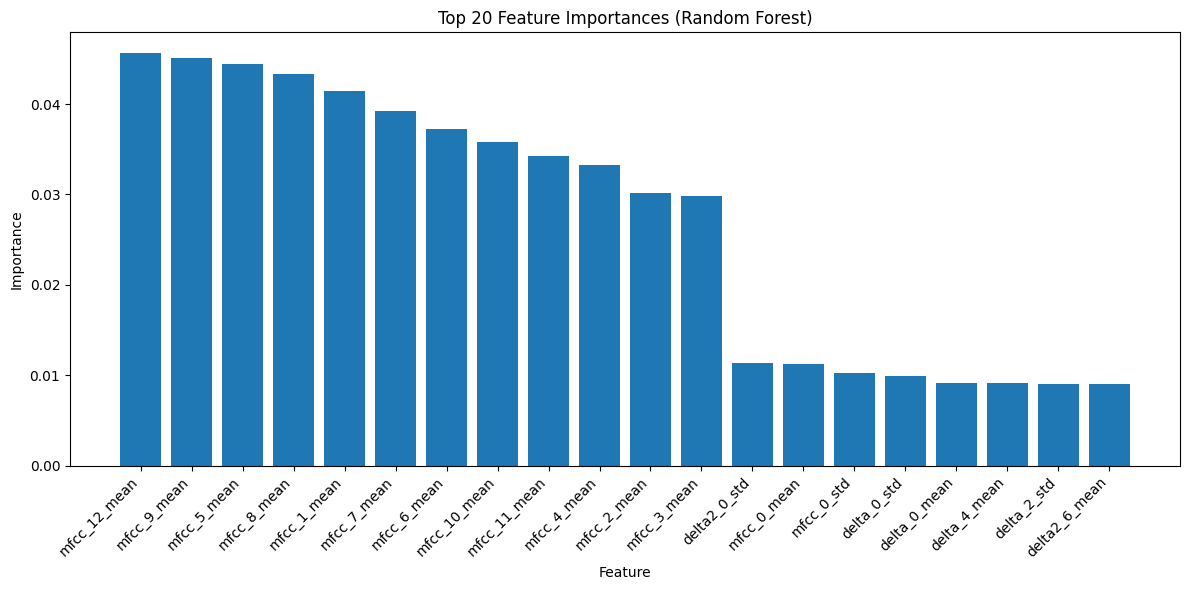

In [ ]:
# Get feature importance from Random Forest
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_

# Create feature names
feature_names = []
for stat in ['mean', 'std']:
    for feat_type in ['mfcc', 'delta', 'delta2']:
        for i in range(13):
            feature_names.append(f"{feat_type}_{i}_{stat}")

# Sort by importance
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save Best Model


In [ ]:
# Save the best model and scaler
best_result = results[best_model_name]

model_data = {
    'model': best_model,
    'scaler': scaler,
    'model_name': best_model_name,
    'accuracy': best_result['accuracy'],
    'f1_score': best_result['f1_score'],
    'class_names': CLASS_NAMES
}

joblib.dump(model_data, MODEL_DIR / 'traditional_ml_classifier.joblib')
print(f"Saved best model ({best_model_name}) to {MODEL_DIR / 'traditional_ml_classifier.joblib'}")

# Also save all results
summary_df.to_csv(OUTPUT_DIR / 'traditional_ml_results.csv', index=False)
print(f"Saved results summary to {OUTPUT_DIR / 'traditional_ml_results.csv'}")


Saved best model (XGBoost) to ../outputs/models/traditional_ml_classifier.joblib
Saved results summary to ../outputs/traditional_ml_results.csv


In [ ]:
print("\n" + "="*60)
print("TRADITIONAL ML CLASSIFIER SUMMARY")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {best_result['accuracy']:.2%}")
print(f"Test F1 Score: {best_result['f1_score']:.4f}")
print(f"\nFeatures: 78 (39 MFCC stats x mean/std)")
print(f"Class balancing: SMOTE")
print(f"\nComparison to literature:")
print(f"  Chen et al. (2024): 98.8% accuracy")
print(f"  Our result: {best_result['accuracy']:.1%}")



TRADITIONAL ML CLASSIFIER SUMMARY

Best Model: XGBoost
Test Accuracy: 78.83%
Test F1 Score: 0.7873

Features: 78 (39 MFCC stats x mean/std)
Class balancing: SMOTE

Comparison to literature:
  Chen et al. (2024): 98.8% accuracy
  Our result: 78.8%
